# SIT307 8.1D – Sydney House Price Prediction
Ayaan Ali | Suburbs: Marrickville (inner-west, ~7 km), Cronulla (beach, ~26 km), Springwood (lower Blue Mountains, ~70 km)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, sklearn

from sklearn.model_selection import KFold, cross_validate, cross_val_predict, validation_curve, train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


## Part 1 – Data collection and quality

In [3]:
from google.colab import files
uploaded = files.upload()          # a "Choose Files" button appears – pick the CSV
print(list(uploaded.keys()))       # shows the exact file name Colab received

Saving sydney_sold_properties_2.csv to sydney_sold_properties_2.csv
['sydney_sold_properties_2.csv']


In [8]:
df = pd.read_csv(list(uploaded.keys())[0])
df["sale_date"] = pd.to_datetime(df["sale_date"], dayfirst=True)
print("Rows loaded:", len(df))

df = df.drop_duplicates(subset=["address"])
df = df[df["property_type"] != "Block of units"]   # a whole building, not one home

# Group similar property types so each group has enough rows
df["property_type"] = df["property_type"].replace({
    "Unit": "Apartment/Unit", "Apartment": "Apartment/Unit", "Studio": "Apartment/Unit",
    "Villa": "Townhouse/Villa", "Townhouse": "Townhouse/Villa",
    "Duplex/semi-detached": "House",
})
print("Rows after cleaning:", len(df))

print("\nProperties per suburb:\n", df["suburb"].value_counts())
print("\nProperty types:\n", df["property_type"].value_counts())
print("\nMissing values (%):\n", (df.isna().mean() * 100).round(1))
df.describe()

Rows loaded: 117
Rows after cleaning: 116

Properties per suburb:
 suburb
Springwood      40
Cronulla        39
Marrickville    37
Name: count, dtype: int64

Property types:
 property_type
House              66
Apartment/Unit     25
Townhouse/Villa    25
Name: count, dtype: int64

Missing values (%):
 suburb                0.0
address               0.0
sale_price            0.0
sale_date             0.0
property_type         0.0
bedrooms              0.0
bathrooms             0.0
car_spaces           17.2
land_size_sqm        49.1
building_size_sqm    85.3
station_min           0.0
description           0.0
listing_url           0.0
dtype: float64


,sale_price,sale_date,bedrooms,bathrooms,car_spaces,land_size_sqm,building_size_sqm,station_min
count,1.160000e+02,116,116.000000,116.00000,96.000000,59.000000,17.000000,116.000000
mean,1.867302e+06,2026-01-09 02:16:33.103448320,2.922414,1.62069,1.656250,930.579661,119.352941,3.336207
min,4.200000e+05,2024-05-01 00:00:00,1.000000,1.00000,1.000000,132.800000,63.000000,1.000000
25%,8.975000e+05,2025-08-25 12:00:00,2.000000,1.00000,1.000000,330.000000,75.000000,2.000000
50%,1.567750e+06,2026-04-05 12:00:00,3.000000,1.00000,1.000000,581.700000,97.000000,3.000000
75%,2.510000e+06,2026-08-12 18:00:00,4.000000,2.00000,2.000000,727.150000,155.000000,4.000000
max,8.750000e+06,2026-09-16 00:00:00,5.000000,3.00000,5.000000,22300.000000,227.000000,14.000000
std,1.343364e+06,NaN,0.996959,0.70594,0.880528,2844.230349,55.630411,1.793437


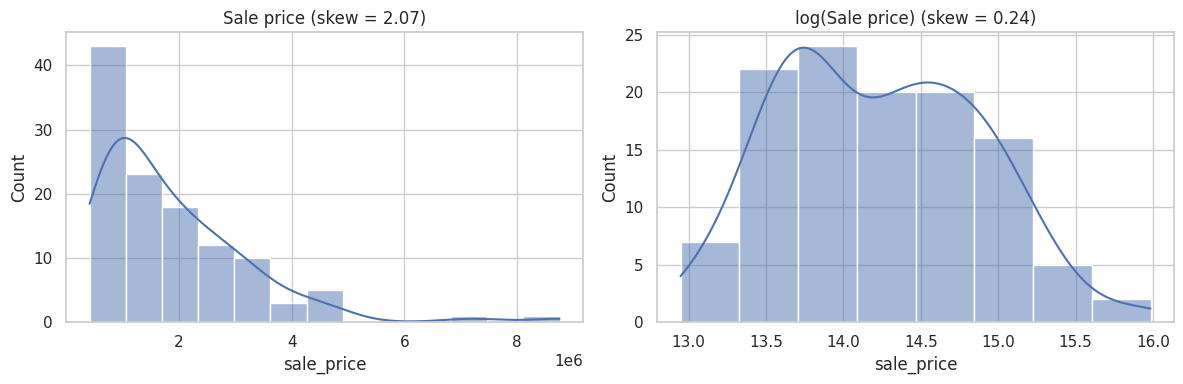

In [10]:
skew_raw = df["sale_price"].skew()
skew_log = np.log(df["sale_price"]).skew()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["sale_price"], kde=True, ax=ax[0]).set_title(f"Sale price (skew = {skew_raw:.2f})")
sns.histplot(np.log(df["sale_price"]), kde=True, ax=ax[1]).set_title(f"log(Sale price) (skew = {skew_log:.2f})")
plt.tight_layout(); plt.show()

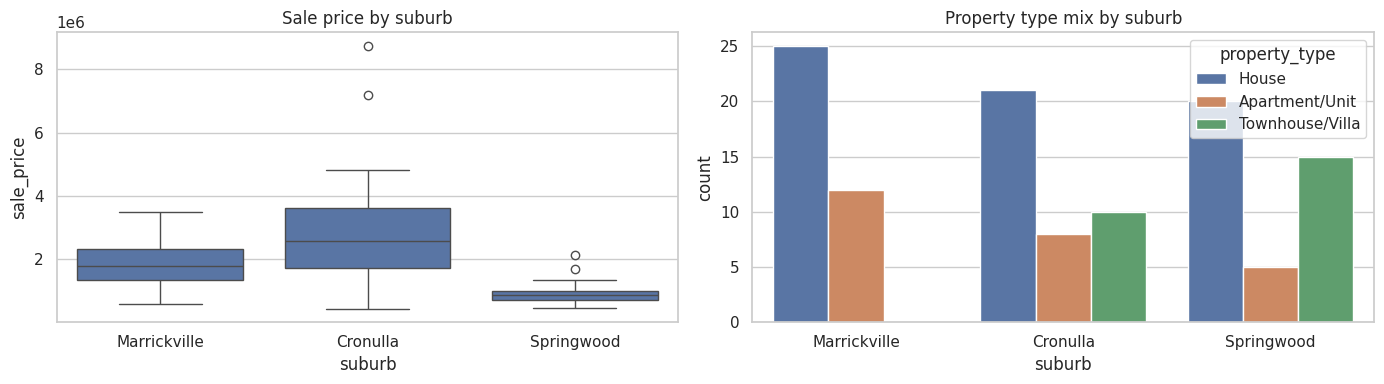

count     median      min      max
suburb       property_type                                      
Cronulla     Apartment/Unit       8   970000.0   420000  7200000
             House               21  3450000.0  1650000  8750000
             Townhouse/Villa     10  1855000.0  1290000  3250000
Marrickville Apartment/Unit      12  1012500.0   590000  1730000
             House               25  2185000.0  1560000  3500000
Springwood   Apartment/Unit       5   490000.0   455000   670000
             House               20   987500.0   813000  2130000
             Townhouse/Villa     15   751000.0   610000  1125000

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=df, x="suburb", y="sale_price", ax=ax[0]).set_title("Sale price by suburb")
sns.countplot(data=df, x="suburb", hue="property_type", ax=ax[1]).set_title("Property type mix by suburb")
plt.tight_layout(); plt.show()

df.groupby(["suburb", "property_type"])["sale_price"].agg(["count", "median", "min", "max"]).round(0)

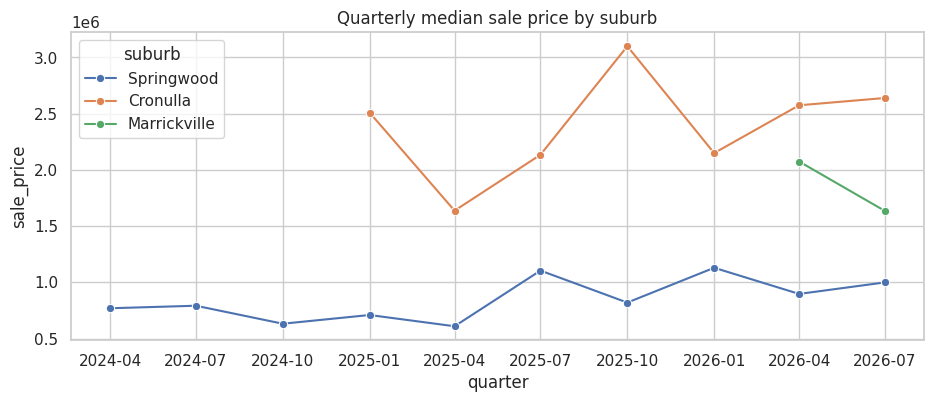

In [12]:
quarterly = (df.assign(quarter=df["sale_date"].dt.to_period("Q").dt.to_timestamp())
               .groupby(["quarter", "suburb"])["sale_price"].median().reset_index())

plt.figure(figsize=(11, 4))
sns.lineplot(data=quarterly, x="quarter", y="sale_price", hue="suburb", marker="o")
plt.title("Quarterly median sale price by suburb"); plt.show()

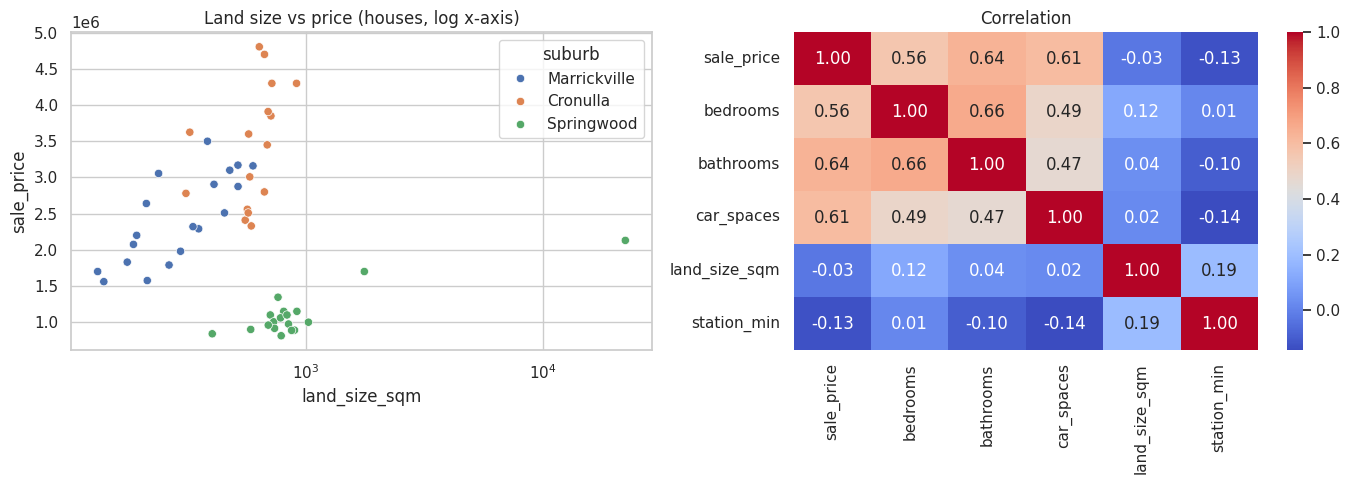

Outliers found: 6


,suburb,address,property_type,bedrooms,land_size_sqm,sale_price
59,Cronulla,39 Darook Park Road,House,3,NaN,8750000
69,Cronulla,65a The Esplanade,Apartment/Unit,4,NaN,7200000
83,Springwood,167 Burns Road,House,4,22300.0,2130000
84,Springwood,4/5 Moorecourt Avenue,Apartment/Unit,2,NaN,670000
86,Springwood,3/409 Great Western Highway,Townhouse/Villa,3,NaN,1125000
97,Springwood,13 Spring Street,House,4,1769.0,1700000


In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
houses = df[df["property_type"] == "House"]
sns.scatterplot(data=houses, x="land_size_sqm", y="sale_price", hue="suburb", ax=ax[0])
ax[0].set_xscale("log"); ax[0].set_title("Land size vs price (houses, log x-axis)")

num = ["sale_price", "bedrooms", "bathrooms", "car_spaces", "land_size_sqm", "station_min"]
sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax[1]).set_title("Correlation")
plt.tight_layout(); plt.show()

g = df.groupby(["suburb", "property_type"])["sale_price"]
q1, q3 = g.transform(lambda s: s.quantile(.25)), g.transform(lambda s: s.quantile(.75))
iqr = q3 - q1
df["is_outlier"] = ((df["sale_price"] < q1 - 1.5 * iqr) |
                    (df["sale_price"] > q3 + 1.5 * iqr) |
                    (df["land_size_sqm"] > 5000))
print("Outliers found:", df["is_outlier"].sum())
df.loc[df["is_outlier"], ["suburb", "address", "property_type", "bedrooms", "land_size_sqm", "sale_price"]]

## Part 2 – Feature engineering

**My top 3 predictors (chosen before modelling):**
1. **Suburb** – location sets the price level (Cronulla beach premium vs Springwood).
2. **Bedrooms / property type** – bigger houses sell for more than units.
3. **Land size** – land is the scarce asset in Sydney.

In [14]:
df["days_since_start"] = (df["sale_date"] - df["sale_date"].min()).dt.days   # market trend
df["total_rooms"]      = df["bedrooms"] + df["bathrooms"]                    # overall size
df["land_per_bed"]     = df["land_size_sqm"] / df["bedrooms"]                # spaciousness
df["is_strata"]        = (df["property_type"] != "House").astype(int)        # unit/townhouse vs house

# Keyword features from the agent descriptions
desc = df["description"].fillna("").str.lower()
keywords = {
    "has_pool":        r"\bpool\b",
    "is_renovated":    r"renovated|brand-new|brand new|newly",
    "needs_work":      r"renovate|restore|original condition|opportunity|potential",
    "has_view":        r"\bviews?\b|outlook|skyline|ocean|water",
    "has_granny_flat": r"granny|secondary dwelling",
}
for col, pattern in keywords.items():
    df[col] = desc.str.contains(pattern, regex=True).astype(int)

print("Listings mentioning each keyword:\n", df[list(keywords)].sum())
print("\nMedian price with / without a pool:\n", df.groupby("has_pool")["sale_price"].median())

Listings mentioning each keyword:
 has_pool            9
is_renovated       14
needs_work         44
has_view           16
has_granny_flat     1
dtype: int64

Median price with / without a pool:
 has_pool
0    1350000.0
1    2820000.0
Name: sale_price, dtype: float64


In [15]:
base_num = ["bedrooms", "bathrooms", "car_spaces", "land_size_sqm", "station_min"]
eng_num  = ["days_since_start", "total_rooms", "land_per_bed", "is_strata"]
bin_cols = list(keywords)
cat_cols = ["suburb", "property_type"]

def make_model(estimator, num_cols, use_bin=True):
    transformers = [
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                          ("sc", StandardScaler())]), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
    if use_bin:
        transformers.append(("bin", "passthrough", bin_cols))
    pipe = Pipeline([("pre", ColumnTransformer(transformers)), ("model", estimator)])
    # Train on log(price), give predictions back in dollars
    return TransformedTargetRegressor(regressor=pipe, func=np.log, inverse_func=np.exp)

num_cols = base_num + eng_num
X = df[num_cols + bin_cols + cat_cols]
y = df["sale_price"]
print("X shape:", X.shape)

X shape: (116, 16)


## Part 3 – Model training and evaluation

**Why these 3 models:** Linear Regression (simple, interpretable baseline), KNN (similar houses sell for similar prices), Random Forest (non-linear, captures interactions like land mattering more in some suburbs). With ~116 rows, more models would add noise, not insight.

**My prediction:** Random Forest will perform best.

In [16]:
models = {
    "Linear Regression": LinearRegression(),
    "KNN Regressor":     KNeighborsRegressor(n_neighbors=5),
    "Random Forest":     RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=42),
}
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error",
           "MAPE": "neg_mean_absolute_percentage_error", "R2": "r2"}

rows = []
for name, est in models.items():
    cv = cross_validate(make_model(est, num_cols), X, y, cv=kf, scoring=scoring, return_train_score=True)
    rows.append({
        "Model": name,
        "Train MAE ($)": -cv["train_MAE"].mean(),
        "Val MAE ($)":   -cv["test_MAE"].mean(),
        "Val RMSE ($)":  -cv["test_RMSE"].mean(),
        "Val MAPE (%)":  -cv["test_MAPE"].mean() * 100,
        "Train R2":       cv["train_R2"].mean(),
        "Val R2":         cv["test_R2"].mean(),
        "Val R2 std":     cv["test_R2"].std(),
    })
results = pd.DataFrame(rows).set_index("Model").round(2)
results

,Train MAE ($),Val MAE ($),Val RMSE ($),Val MAPE (%),Train R2,Val R2,Val R2 std
Model,,,,,,,
Linear Regression,297785.16,373688.97,704346.81,17.49,0.78,0.71,0.15
KNN Regressor,455109.82,527057.10,861230.13,29.14,0.60,0.56,0.16
Random Forest,204022.95,367075.11,677133.24,17.22,0.86,0.72,0.17


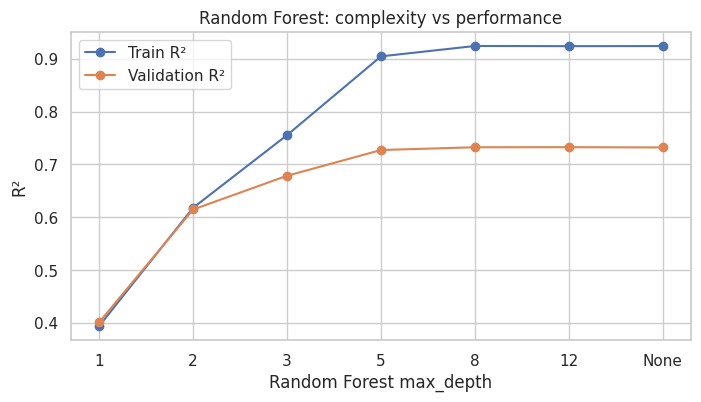

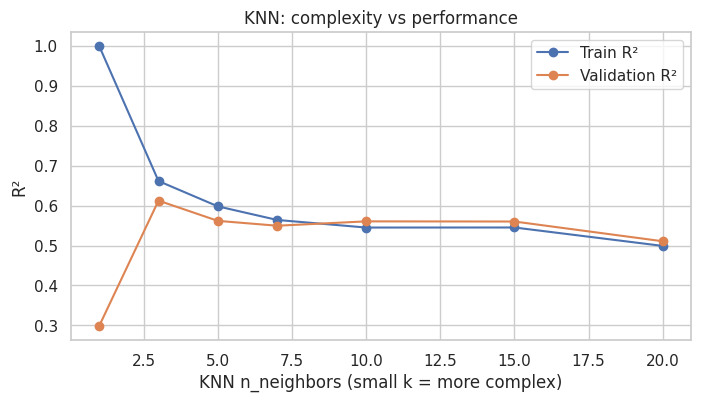

In [17]:
depths = [1, 2, 3, 5, 8, 12, None]
train_s, val_s = validation_curve(
    make_model(RandomForestRegressor(n_estimators=200, random_state=42), num_cols),
    X, y, param_name="regressor__model__max_depth", param_range=depths, cv=kf, scoring="r2")
labels = [str(d) for d in depths]
plt.figure(figsize=(8, 4))
plt.plot(labels, train_s.mean(1), marker="o", label="Train R²")
plt.plot(labels, val_s.mean(1), marker="o", label="Validation R²")
plt.xlabel("Random Forest max_depth"); plt.ylabel("R²"); plt.legend()
plt.title("Random Forest: complexity vs performance"); plt.show()

ks = [1, 3, 5, 7, 10, 15, 20]
tr_k, va_k = validation_curve(make_model(KNeighborsRegressor(), num_cols), X, y,
                              param_name="regressor__model__n_neighbors", param_range=ks, cv=kf, scoring="r2")
plt.figure(figsize=(8, 4))
plt.plot(ks, tr_k.mean(1), marker="o", label="Train R²")
plt.plot(ks, va_k.mean(1), marker="o", label="Validation R²")
plt.xlabel("KNN n_neighbors (small k = more complex)"); plt.ylabel("R²"); plt.legend()
plt.title("KNN: complexity vs performance"); plt.show()

## Part 4 – Investigating prediction errors

In [18]:
best_name = results["Val MAE ($)"].idxmin()
print("Best model:", best_name)
best = make_model(models[best_name], num_cols)

# Out-of-fold predictions: each house is predicted by a model that never saw it
df["predicted"] = cross_val_predict(best, X, y, cv=kf)
df["error"]     = df["predicted"] - df["sale_price"]
df["abs_error"] = df["error"].abs()
df["pct_error"] = 100 * df["abs_error"] / df["sale_price"]

top5 = df.nlargest(5, "abs_error")
top5[["suburb", "address", "property_type", "bedrooms", "land_size_sqm",
      "sale_price", "predicted", "error", "pct_error", "description"]].round(0)

Best model: Random Forest


,suburb,address,property_type,bedrooms,land_size_sqm,sale_price,predicted,error,pct_error,description
59,Cronulla,39 Darook Park Road,House,3,NaN,8750000,3210707.0,-5539293.0,63.0,Positioned in one of Cronulla's most tightly h...
69,Cronulla,65a The Esplanade,Apartment/Unit,4,NaN,7200000,3155841.0,-4044159.0,56.0,Nestled along the pristine shores of Shelley B...
55,Cronulla,175 Ewos Parade,House,3,638.0,4805000,2675387.0,-2129613.0,44.0,Step into a world of timeless style and effort...
61,Cronulla,20 Dodson Avenue,House,4,689.0,3450000,5071264.0,1621264.0,47.0,Nestled in one of Cronulla's most exclusive cu...
37,Cronulla,22 Chelmsford Avenue,House,5,NaN,4500000,3016350.0,-1483650.0,33.0,Set within a tightly held South Cronulla encla...


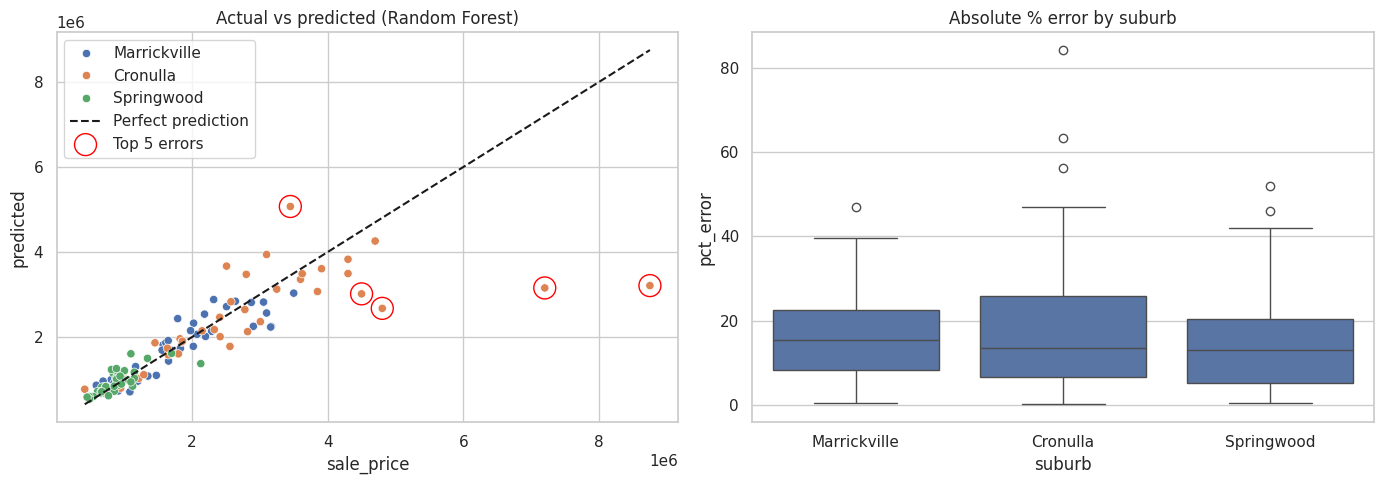

Median absolute error: $177,003
Median % error: 13.8%
Predictions within 10%: 37%
Predictions within 20%: 70%


,abs_error,pct_error
suburb,,
Cronulla,256931.7,13.5
Marrickville,237112.1,15.4
Springwood,114117.2,13.0


In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="sale_price", y="predicted", hue="suburb", ax=ax[0])
lims = [df[["sale_price", "predicted"]].min().min(), df[["sale_price", "predicted"]].max().max()]
ax[0].plot(lims, lims, "k--", label="Perfect prediction")
ax[0].scatter(top5["sale_price"], top5["predicted"], s=250, facecolors="none", edgecolors="red", label="Top 5 errors")
ax[0].set_title(f"Actual vs predicted ({best_name})"); ax[0].legend()

sns.boxplot(data=df, x="suburb", y="pct_error", ax=ax[1]).set_title("Absolute % error by suburb")
plt.tight_layout(); plt.show()

print(f"Median absolute error: ${df['abs_error'].median():,.0f}")
print(f"Median % error: {df['pct_error'].median():.1f}%")
print(f"Predictions within 10%: {(df['pct_error'] <= 10).mean() * 100:.0f}%")
print(f"Predictions within 20%: {(df['pct_error'] <= 20).mean() * 100:.0f}%")
df.groupby("suburb")[["abs_error", "pct_error"]].median().round(1)

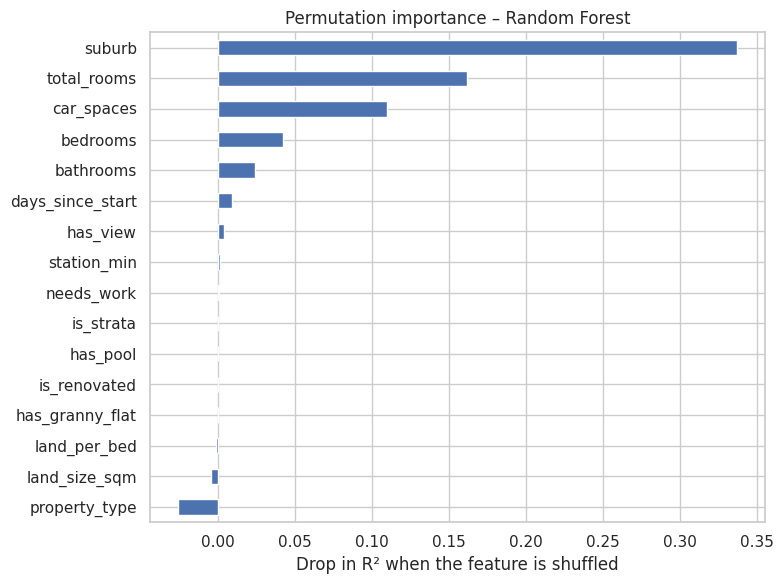

,0
suburb,0.337
total_rooms,0.161
car_spaces,0.110
bedrooms,0.042
bathrooms,0.024
days_since_start,0.009
has_view,0.004
station_min,0.001
needs_work,0.001
is_strata,0.000


In [20]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=df["suburb"])
imp_model = make_model(models[best_name], num_cols).fit(X_tr, y_tr)
imp = permutation_importance(imp_model, X_te, y_te, n_repeats=30, random_state=42, scoring="r2")

importance = pd.Series(imp.importances_mean, index=X.columns).sort_values()
importance.plot.barh(figsize=(8, 6), title=f"Permutation importance – {best_name}")
plt.xlabel("Drop in R² when the feature is shuffled")
plt.tight_layout(); plt.show()
importance.sort_values(ascending=False).round(3)

In [21]:
def cv_mae(model, Xd, yd):
    return -cross_validate(model, Xd, yd, cv=kf, scoring="neg_mean_absolute_error")["test_score"].mean()

est  = models[best_name]
keep = ~df["is_outlier"]
experiments = {
    "1. Base features only":           cv_mae(make_model(est, base_num, use_bin=False), X, y),
    "2. Base + engineered + keywords": cv_mae(make_model(est, num_cols), X, y),
    "3. Same as 2, outliers removed":  cv_mae(make_model(est, num_cols), X[keep], y[keep]),
}
pd.Series(experiments, name="CV MAE ($)").round(0)

,CV MAE ($)
1. Base features only,353056.0
2. Base + engineered + keywords,367075.0
"3. Same as 2, outliers removed",286242.0


**Findings:**
- **Magnitude:** median error $177K (13.8%), but mean error $367K – a few huge misses inflate the average. 70% of predictions are within 20% of the sale price, only 37% within 10%.
- **Largest errors:** all five are high-value Cronulla homes. Four were under-predicted (e.g. 39 Darook Park Rd by $5.5M; 65a The Esplanade, on Shelley Beach, by $4.0M). The dataset has no feature for water frontage or beach access, so the model cannot see what makes these homes unique.
- **By suburb:** % error is similar everywhere (13–15%); Marrickville is highest at 15.4%. Cronulla only looks worst in dollars because its homes cost more.
- **Feature importance:** suburb dominates (0.34), then total rooms and car spaces. This confirms my prediction that location matters most, but land size was not important – large Springwood blocks are cheap, so land size alone does not signal a high price.
- **Engineered features did not help:** base features alone gave MAE $353K vs $367K with engineered + keyword features. With only 116 rows, extra columns add noise, and keywords were too rare (9 pools, 1 granny flat) to learn from.
- **Remove data or better features?** Removing 6 outliers lowered MAE to $286K, but that only hides the hardest cases – the model is no better at pricing them. The better fix is more informative features (water frontage, distance to beach, street/aspect, condition, auction vs private sale) and more sales per suburb.
- **Complexity:** Random Forest overfits beyond depth 5 (train R² 0.92 vs validation 0.73); KNN overfits badly at k = 1 (validation R² 0.30) and underfits at large k.

In [22]:
final_model = make_model(models[best_name], num_cols).fit(X, y)
bundle = {
    "model": final_model,
    "model_name": best_name,
    "start_date": df["sale_date"].min(),
    "suburbs": sorted(df["suburb"].unique()),
    "types": sorted(df["property_type"].unique()),
    "keywords": keywords,
}
joblib.dump(bundle, "model.joblib")
print("Saved model.joblib using", best_name)

Saved model.joblib using Random Forest
